# XD Example
# Import Data and Functions

In [1]:
import numpy as np
from matplotlib import pyplot as plt

from astroML.density_estimation import XDGMM
from astroML.plotting.tools import draw_ellipse

from astroML.crossmatch import crossmatch
from astroML.datasets import fetch_sdss_S82standards, fetch_imaging_sample
from astroML.stats import sigmaG

## A. XD on a generated dataset

### A1. Generate true data (per comparar-la amb l'estimació XD)

Primero generamos una distribución de "datos verdaderos" usando números randomizados. Trazaremos este conjunto de datos como referencia para compararlo con el modelo derivado de la estimación con XD.
Los usuarios pueden cambiar el tamaño de la muestra (N) para experimentar la efectividad de este método: un tamaño de muestra más grande brinda más información sobre el conjunto de datos y es más fácil de converger; sin embargo, lleva más tiempo ejecutar el método. Es posible que el método no converja debido al pequeño tamaño de la muestra.

x_true:
[ 6.37883073  7.98514057  6.76379532  6.41889758  4.76100621  7.11698594
  5.08047587 10.14807452 11.06550173  4.61464236  8.89170035  6.0182378
  6.29020578 10.45985288  2.59962028  1.80897955  0.8837726   9.35031491
  8.71576626 10.17828015 11.17837919  9.13091712  5.57349783  8.58710866
  3.18680448  6.97134661  1.26490165 10.90109238  5.59910866  5.08800495
  3.45551134  8.94724948  5.60309216  6.34657403  1.35365493  6.72255109
  6.80509727  6.88592307 10.75867265  7.66412491  4.6628539   5.2586305
  7.68701122  1.09185819  7.70641481  7.39681049  3.01255261  2.42037996
  3.50667629  4.38478883  6.35956721  5.3399669  11.49375904  2.57575879
  3.73881405  3.15584481  7.32087081  3.69986804  5.39629901  3.40419417
  2.80159075  1.86013382  7.40728074  2.20786707  3.62521538  4.495943
  9.26094314  2.89668794  9.55417711  1.40046469 11.21482657  5.66897035
 11.02259475  6.88261404  7.92895053  1.22712029  3.87785253  1.61001798
  3.62041155  1.71515741  4.69365357  5.0093848

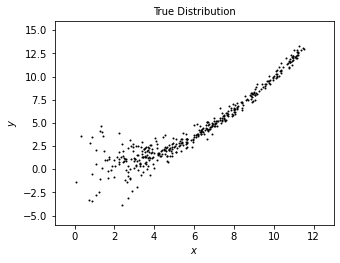

In [2]:
# Sample the dataset. 
# Here we use sample size = 400 in the example, 
# which converges in shorter time, and gives reasonable result.
N = 400
np.random.seed(0)

# generate the true data
x_true = (1.4 + 2 * np.random.random(N)) ** 2
y_true = 0.1 * x_true ** 2

# afegim dispersió a les dades "reals"
dx = 0.1 + 4. / x_true ** 2
dy = 0.1 + 10. / x_true ** 2


#columnes de dades a plotejar
x_true += np.random.normal(0, dx, N)
y_true += np.random.normal(0, dy, N)

print('x_true:')
print(x_true)
print('y_true:')
print(y_true)

# define a function to plot all distributions in the same format
def plot_distribution(text, sample_x, sample_y):
    plt.figure(figsize=(5, 3.75))
    plt.scatter(sample_x, sample_y, s=4,lw=0,c='k')
    plt.xlim(-1, 13)
    plt.ylim(-6, 16)
    plt.xlabel('$x$')
    plt.ylabel('$y$')
    plt.title(text,fontsize=10)

# plot true distribution
plot_distribution('True Distribution', x_true, y_true)

plt.show()

### A2. Generate noisy data¶
Agregamos algo de radom ruidoso a los datos verdaderos para modelar lo que podemos observar a partir de la distribución verdadera.

x_dim: (400,)
x_noisy:
[ 7.17139592  7.42450495  6.35606753  6.51299355  5.14495871  6.94827572
  5.23519934  9.94606865 10.61556611  5.2835463  10.5560486   6.61622708
  6.38829584 11.65353959  2.75234565  1.51844269  1.15638242  9.29944231
  8.36192537  9.91037763 11.60808951  7.98332215  5.69923463  7.73744102
  2.29286328  5.77785448  1.97438514 10.81532     5.63871038  5.47151571
  3.97533206  8.09114232  5.8020552   6.41024446  1.27881979  6.73902694
  7.48798501  6.28160514 10.945384    7.65832058  3.9669792   4.95625365
  7.76219717  1.77806272  8.08664681  7.78510834  2.44867745  2.80802509
  3.57056217  4.12703346  6.31911192  5.62127284 11.49698427  3.12428033
  4.08196576  3.33487106  6.75066207  3.77214765  5.42335514  4.28830775
  1.67904931  1.79348689  7.27717078  2.30806077  2.64437162  5.05411725
  9.26899928  2.14673748  9.35374879  1.76275755 10.64408546  5.6711925
 10.46760271  6.52650617  7.94173065  1.33183398  3.60234011  1.78846069
  3.84549844  1.58151795  5.2

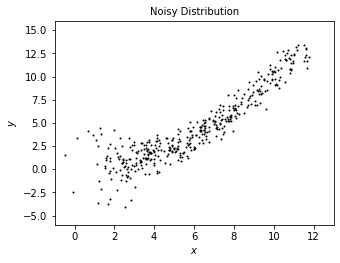

In [3]:
# afegim soroll per obtenir dades "experimentals"
dx = 0.2 + 0.5 * np.random.random(N)
dy = 0.2 + 0.5 * np.random.random(N)

x = x_true + np.random.normal(0, dx)  #dim = 400x1
y = y_true + np.random.normal(0, dy)

print('x_dim:', x.shape)
print('x_noisy:')
print(x)
print('y_dim:', y.shape)
print('y_noisy:')
print(y)

# plot noisy distribution
plot_distribution('Noisy Distribution', x, y)

### A3. Compute extreme deconvolution (XD) (sobre les dades noisy)
El siguiente código calcula el resultado. En el método XDGMM, n_components (integer) define el número de componentes gaussianos que se ajustan a los datos.
max_iter (integer) define el número de iteraciones EM a realizar (predeterminado como 100). Un número de iteración más grande generalmente contribuye a una mejor aproximación a los datos verdaderos, pero lleva más tiempo ejecutarlo.
Se espera que esta celda se ejecute en un poco más de 1 minuto.

In [ ]:
# stack the results for computation
X = np.vstack([x, y]).T   #vertical stack (concatenació vertical) de les dades noisy i transposició
Xerr = np.zeros(X.shape + X.shape[-1:])

# X.shape: (400, 2)
# X.shape[-1:] : (2,)
# X.shape + X.shape[-1:] : (400, 2, 2)
# Xerr = np.zeros(400, 2, 2)

diag = np.arange(X.shape[-1]) #[0 1]
Xerr[:, diag, diag] = np.vstack([dx ** 2, dy ** 2]).T

print('X dim:', X.shape)
print('Xerr dim:', Xerr.shape)
print('Posicions de les estrelles:')
print('X:\tx\t    y')
print(X)
print('Xerr:')
print(Xerr)


clf = XDGMM(n_components=10, max_iter=200)
'''n_components: nombre de components gaussians que s'ajusten a les dades'''
   
clf.fit(X, Xerr)
sample = clf.sample(N)

X dim: (400, 2)
Xerr dim: (400, 2, 2)
Posicions de les estrelles:
X:	x	    y
[[ 7.17139592  4.29940251]
 [ 7.42450495  5.89814693]
 [ 6.35606753  4.07741713]
 [ 6.51299355  4.23772385]
 [ 5.14495871  2.13923388]
 [ 6.94827572  5.21744504]
 [ 5.23519934  3.27639463]
 [ 9.94606865 10.44478623]
 [10.61556611 11.79665537]
 [ 5.2835463   1.77720381]
 [10.5560486   9.43054175]
 [ 6.61622708  3.22916593]
 [ 6.38829584  3.81898961]
 [11.65353959 10.93457039]
 [ 2.75234565  1.10499758]
 [ 1.51844269  0.38486927]
 [ 1.15638242 -3.60237762]
 [ 9.29944231  8.47745944]
 [ 8.36192537  7.30384648]
 [ 9.91037763 10.30887407]
 [11.60808951 12.34790528]
 [ 7.98332215  8.04049065]
 [ 5.69923463  1.18127888]
 [ 7.73744102  6.80333267]
 [ 2.29286328 -0.08305626]
 [ 5.77785448  5.11508302]
 [ 1.97438514  4.2643635 ]
 [10.81532    10.78336917]
 [ 5.63871038  3.46945779]
 [ 5.47151571  1.86912743]
 [ 3.97533206  0.47260355]
 [ 8.09114232  7.6611981 ]
 [ 5.8020552   2.36858672]
 [ 6.41024446  3.16829913]
 [ 1.

### A4. Plot the result from XD
Usamos puntos dispersos para mostrar el resultado de datos ruidosos de la corrección XD. El gráfico muestra una distribución menos dispersa que los datos ruidosos e incluso que los datos verdaderos, lo que retrata mejor una "distribución subyacente".

In [ ]:
# plot noisy distribution
#                                                          x              y
plot_distribution('Extreme Deconvolution Resampling', sample[:, 0], sample[:, 1])

### A5. Use subplots to show clear comparison
Trazamos la distribución verdadera (arriba a la izquierda), la distribución ruidosa (arriba a la derecha) y la distribución remuestreada de XD (abajo a la izquierda) juntas para mostrar una comparación clara de la efectividad de este método en el modelado.
Además, agregamos una representación agrupada de la distribución (abajo a la derecha) para mostrar el uso en la localización de agrupaciones con el método XD.

In [ ]:
# Plot the results
fig = plt.figure(figsize=(5, 3.75))
fig.subplots_adjust(left=0.1, right=0.95,
                    bottom=0.1, top=0.95,
                    wspace=0.02, hspace=0.02)

ax1 = fig.add_subplot(221)
ax1.scatter(x_true, y_true, s=4, lw=0, c='k')

ax2 = fig.add_subplot(222)
ax2.scatter(x, y, s=4, lw=0, c='k')

ax3 = fig.add_subplot(223)
ax3.scatter(sample[:, 0], sample[:, 1], s=4, lw=0, c='k')

ax4 = fig.add_subplot(224)
for i in range(clf.n_components):
    draw_ellipse(clf.mu[i], clf.V[i], scales=[2], ax=ax4,
                 ec='k', fc='gray', alpha=0.2)

titles = ["True Distribution", "Noisy Distribution",
          "Extreme Deconvolution\n  resampling",
          "Extreme Deconvolution\n  cluster locations"]

ax = [ax1, ax2, ax3, ax4]

for i in range(4):
    ax[i].set_xlim(-1, 13)
    ax[i].set_ylim(-6, 16)

    ax[i].xaxis.set_major_locator(plt.MultipleLocator(4))
    ax[i].yaxis.set_major_locator(plt.MultipleLocator(5))

    ax[i].text(0.05, 0.95, titles[i],
               ha='left', va='top', transform=ax[i].transAxes)

    if i in (0, 1):
        ax[i].xaxis.set_major_formatter(plt.NullFormatter())
    else:
        ax[i].set_xlabel('$x$')

    if i in (1, 3):
        ax[i].yaxis.set_major_formatter(plt.NullFormatter())
    else:
        ax[i].set_ylabel('$y$')

## B. XD on real star sample


### B1. Perform extinction correction on noisy sample


In [ ]:
# define u-g-r-i-z extinction from Berry et al, arXiv 1111.4985 multiply extinction by A_r
extinction_vector = np.array([1.810, 1.400, 1.0, 0.759, 0.561])

# Fetch and process the noisy imaging data (obtenir i processar les dades d'imatges amb soroll)
data_noisy = fetch_imaging_sample()

# select only stars (seleccionem només les estrelles)
data_noisy = data_noisy[data_noisy['type'] == 6]

# Get the extinction-corrected magnitudes for each band
X = np.vstack([data_noisy[f + 'RawPSF'] for f in 'ugriz']).T
Xerr = np.vstack([data_noisy[f + 'psfErr'] for f in 'ugriz']).T
print('Magnituds u-g-r-i-z (columnes) per cada estrella (files),\t', X.shape)
print(X)
print("Matriu d'errors,\t", Xerr.shape)
print(Xerr)

# extinction terms from Berry et al, arXiv 1111.4985
X -= (extinction_vector * data_noisy['rExtSFD'][:, None])

### B2. Perform extinction correction on standard sample


In [ ]:
# Fetch and process the stacked imaging data (Obtener y procesar los datos de imágenes apilados)
data_stacked = fetch_sdss_S82standards()

# cut to RA, DEC range of imaging sample
RA = data_stacked['RA']
DEC = data_stacked['DEC']
data_stacked = data_stacked[(RA > 0) & (RA < 10) &
                            (DEC > -1) & (DEC < 1)]

# get stacked magnitudes for each band
Y = np.vstack([data_stacked['mmu_' + f] for f in 'ugriz']).T
Yerr = np.vstack([data_stacked['msig_' + f] for f in 'ugriz']).T

# extinction terms from Berry et al, arXiv 1111.4985
Y -= (extinction_vector * data_stacked['A_r'][:, None])

# quality cuts
g = Y[:, 1]
mask = ((Yerr.max(1) < 0.05) &
        (g < 20))
data_stacked = data_stacked[mask]
Y = Y[mask]
Yerr = Yerr[mask]

### B3. Cross-match two data sets


In [ ]:
Xlocs = np.hstack((data_noisy['ra'][:, np.newaxis],  #noisy points
                   data_noisy['dec'][:, np.newaxis]))
Ylocs = np.hstack((data_stacked['RA'][:, np.newaxis],  #stacked points
                   data_stacked['DEC'][:, np.newaxis]))

print("number of noisy points:  ", Xlocs.shape)
print("number of stacked points:", Ylocs.shape)

# find all points within 0.9 arcsec.  This cutoff was selected
# by plotting a histogram of the log(distances).
dist, ind = crossmatch(Xlocs, Ylocs, max_distance=0.9 / 3600)

noisy_mask = (~np.isinf(dist))
stacked_mask = ind[noisy_mask]

# select the data
data_noisy = data_noisy[noisy_mask]
X = X[noisy_mask]
Xerr = Xerr[noisy_mask]

data_stacked = data_stacked[stacked_mask]
Y = Y[stacked_mask]
Yerr = Yerr[stacked_mask]

# double-check that our cross-match succeeded
assert X.shape == Y.shape
print("size after crossmatch:", X.shape)

### B4. Define W matrix and calculate covariance


In [ ]:
# first define mixing matrix W
W = np.array([[0, 1, 0, 0, 0],    # g magnitude
              [1, -1, 0, 0, 0],   # u-g color
              [0, 1, -1, 0, 0],   # g-r color
              [0, 0, 1, -1, 0],   # r-i color
              [0, 0, 0, 1, -1]])  # i-z color

X = np.dot(X, W.T)
Y = np.dot(Y, W.T)

# compute error covariance from mixing matrix
Xcov = np.zeros(Xerr.shape + Xerr.shape[-1:])
Xcov[:, range(Xerr.shape[1]), range(Xerr.shape[1])] = Xerr ** 2

# each covariance C = WCW^T
# best way to do this is with a tensor dot-product
Xcov = np.tensordot(np.dot(Xcov, W.T), W, (-2, -1))

### B5. Plot two raw data sets


In [ ]:
# Fit and sample from the underlying distribution
np.random.seed(42)
X_sample = clf.sample(X.shape[0])

# plot the results
fig = plt.figure(figsize=(10, 3.75))
fig.subplots_adjust(left=0.12, right=0.95,
                    bottom=0.1, top=0.95,
                    wspace=0.02, hspace=0.02)

# only plot 1/10 of the stars for clarity
ax1 = fig.add_subplot(121)
ax1.scatter(Y[::10, 2], Y[::10, 3], s=9, lw=0, c='k')
ax1.set_ylabel('$r-i$')

ax2 = fig.add_subplot(122)
ax2.scatter(X[::10, 2], X[::10, 3], s=9, lw=0, c='k')

titles = ["Standard Stars", "Single Epoch"]
ax = [ax1, ax2]

for i in range(2):
    ax[i].set_xlim(-0.6, 1.8)
    ax[i].set_ylim(-0.6, 1.8)

    ax[i].xaxis.set_major_locator(plt.MultipleLocator(0.5))
    ax[i].yaxis.set_major_locator(plt.MultipleLocator(0.5))

    ax[i].text(0.05, 0.95, titles[i],
               ha='left', va='top', transform=ax[i].transAxes)

    ax[i].set_xlabel('$g-r$')

### B6. Calculate XD value


In [ ]:
def compute_XD(n_clusters=12, rseed=0, max_iter=100, verbose=True):
    np.random.seed(rseed)
    clf = XDGMM(n_clusters, max_iter=max_iter, tol=1E-5, verbose=verbose)
    clf.fit(X, Xcov)
    return clf

clf = compute_XD(12)

### B7. Plot results in comparison


In [ ]:
# Fit and sample from the underlying distribution
np.random.seed(42)
X_sample = clf.sample(X.shape[0])

# plot the results
fig = plt.figure(figsize=(5, 3.75))
fig.subplots_adjust(left=0.12, right=0.95,
                    bottom=0.1, top=0.95,
                    wspace=0.02, hspace=0.02)

# only plot 1/10 of the stars for clarity
ax1 = fig.add_subplot(221)
ax1.scatter(Y[::10, 2], Y[::10, 3], s=9, lw=0, c='k')

ax2 = fig.add_subplot(222)
ax2.scatter(X[::10, 2], X[::10, 3], s=9, lw=0, c='k')

ax3 = fig.add_subplot(223)
ax3.scatter(X_sample[::10, 2], X_sample[::10, 3], s=9, lw=0, c='k')

ax4 = fig.add_subplot(224)
for i in range(clf.n_components):
    draw_ellipse(clf.mu[i, 2:4], clf.V[i, 2:4, 2:4], scales=[2],
                 ec='k', fc='gray', alpha=0.2, ax=ax4)

titles = ["Standard Stars", "Single Epoch",
          "Extreme Deconvolution\n  resampling",
          "Extreme Deconvolution\n  cluster locations"]
ax = [ax1, ax2, ax3, ax4]

for i in range(4):
    ax[i].set_xlim(-0.6, 1.8)
    ax[i].set_ylim(-0.6, 1.8)

    ax[i].xaxis.set_major_locator(plt.MultipleLocator(0.5))
    ax[i].yaxis.set_major_locator(plt.MultipleLocator(0.5))

    ax[i].text(0.05, 0.95, titles[i],
               ha='left', va='top', transform=ax[i].transAxes)

    if i in (0, 1):
        ax[i].xaxis.set_major_formatter(plt.NullFormatter())
    else:
        ax[i].set_xlabel('$g-r$')

    if i in (1, 3):
        ax[i].yaxis.set_major_formatter(plt.NullFormatter())
    else:
        ax[i].set_ylabel('$r-i$')

### B8. Plot width of Locus

In [ ]:
# Second figure: the width of the locus
fig = plt.figure(figsize=(5, 3.75))
ax = fig.add_subplot(111)

labels = ['single epoch', 'standard stars', 'XD resampled']
linestyles = ['solid', 'dashed', 'dotted']
for data, label, ls in zip((X, Y, X_sample), labels, linestyles):
    g = data[:, 0]
    gr = data[:, 2]
    ri = data[:, 3]

    r = g - gr
    i = r - ri

    mask = (gr > 0.3) & (gr < 1.0)
    g = g[mask]
    r = r[mask]
    i = i[mask]

    w = -0.227 * g + 0.792 * r - 0.567 * i + 0.05

    sigma = sigmaG(w)

    ax.hist(w, bins=np.linspace(-0.08, 0.08, 100), linestyle=ls,
            histtype='step', label=label + '\n\t' + r'$\sigma_G=%.3f$' % sigma,
            density=True)

ax.legend(loc=2)
ax.text(0.95, 0.95, '$w = -0.227g + 0.792r$\n$ - 0.567i + 0.05$',
        transform=ax.transAxes, ha='right', va='top')

ax.set_xlim(-0.07, 0.07)
ax.set_ylim(0, 55)

ax.set_xlabel('$w$')
ax.set_ylabel('$N(w)$')